In [1]:
# What this cell does:
# Import all libraries required for final model evaluation,
# visualization, metrics, and loading the trained models.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# What this cell does:
# Load the final engineered datasets created in Notebook 05.
# These datasets contain the 14 ML features and TARGET_AC_POWER.

plant1 = pd.read_csv("../data/final/plant1_features.csv")
plant2 = pd.read_csv("../data/final/plant2_features.csv")

plant1["DATE_TIME"] = pd.to_datetime(plant1["DATE_TIME"])
plant2["DATE_TIME"] = pd.to_datetime(plant2["DATE_TIME"])

print("Plant 1 shape:", plant1.shape)
print("Plant 2 shape:", plant2.shape)

Plant 1 shape: (66640, 25)
Plant 2 shape: (65564, 25)


In [3]:
# What this cell does:
# Define the exact feature set and target used during model training.
# Keeping the same feature order is important when loading saved models.

feature_columns = [
    "hour",
    "minute",
    "day",
    "day_of_week",
    "day_of_year",
    "month",
    "hour_sin",
    "hour_cos",
    "AC_POWER_lag_1",
    "AC_POWER_lag_4",
    "AC_POWER_lag_8",
    "AC_POWER_lag_96",
    "AC_POWER_rolling_mean_4",
    "AC_POWER_rolling_mean_8"
]

target_column = "TARGET_AC_POWER"

print("Number of features:", len(feature_columns))
print("Target:", target_column)

Number of features: 14
Target: TARGET_AC_POWER


In [4]:
# What this cell does:
# Recreate the exact chronological train/validation/test split
# used during model training.
#
# No random shuffling is used because this is a time-series problem.

def chronological_split(df, train_ratio=0.70, val_ratio=0.15):

    df = df.sort_values("DATE_TIME").copy()

    unique_times = np.sort(df["DATE_TIME"].unique())

    n_times = len(unique_times)

    train_end = int(n_times * train_ratio)
    val_end = int(n_times * (train_ratio + val_ratio))

    train_end_time = unique_times[train_end]
    val_end_time = unique_times[val_end]

    train = df[df["DATE_TIME"] < train_end_time].copy()

    validation = df[
        (df["DATE_TIME"] >= train_end_time) &
        (df["DATE_TIME"] < val_end_time)
    ].copy()

    test = df[df["DATE_TIME"] >= val_end_time].copy()

    return train, validation, test

In [5]:
# What this cell does:
# Create the final unseen test datasets for both plants.
# Only the test period will be used for final model evaluation.

plant1_train, plant1_val, plant1_test = chronological_split(plant1)
plant2_train, plant2_val, plant2_test = chronological_split(plant2)

print("Plant 1 test:", plant1_test.shape)
print("Plant 2 test:", plant2_test.shape)

print("\nPlant 1 test period:")
print(
    plant1_test["DATE_TIME"].min(),
    "→",
    plant1_test["DATE_TIME"].max()
)

print("\nPlant 2 test period:")
print(
    plant2_test["DATE_TIME"].min(),
    "→",
    plant2_test["DATE_TIME"].max()
)

Plant 1 test: (10098, 25)
Plant 2 test: (10450, 25)

Plant 1 test period:
2020-06-13 04:30:00 → 2020-06-17 23:30:00

Plant 2 test period:
2020-06-13 01:00:00 → 2020-06-17 23:30:00


In [6]:
# What this cell does:
# Extract the 14 input features and the target variable
# from the untouched test period.

X1_test = plant1_test[feature_columns]
y1_test = plant1_test[target_column]

X2_test = plant2_test[feature_columns]
y2_test = plant2_test[target_column]

print("Plant 1 X_test:", X1_test.shape)
print("Plant 1 y_test:", y1_test.shape)

print("\nPlant 2 X_test:", X2_test.shape)
print("Plant 2 y_test:", y2_test.shape)

Plant 1 X_test: (10098, 14)
Plant 1 y_test: (10098,)

Plant 2 X_test: (10450, 14)
Plant 2 y_test: (10450,)


In [7]:
# What this cell does:
# Load the trained Linear Regression, Random Forest,
# and XGBoost models saved from Notebook 07.
#
# We load the models instead of retraining them.

MODEL_PATH = "../models/"

linear_model_plant1 = joblib.load(
    MODEL_PATH + "linear_regression/plant1_model.pkl"
)

linear_model_plant2 = joblib.load(
    MODEL_PATH + "linear_regression/plant2_model.pkl"
)

rf_model_plant1 = joblib.load(
    MODEL_PATH + "random_forest/plant1_model.pkl"
)

rf_model_plant2 = joblib.load(
    MODEL_PATH + "random_forest/plant2_model.pkl"
)

xgb_model_plant1 = joblib.load(
    MODEL_PATH + "xgboost/plant1_model.pkl"
)

xgb_model_plant2 = joblib.load(
    MODEL_PATH + "xgboost/plant2_model.pkl"
)

print("All trained models loaded successfully.")

All trained models loaded successfully.


In [9]:
# What this cell does:
# Generate final predictions on the completely unseen test period
# using all three trained ML models.

# Plant 1
plant1_test["Persistence"] = plant1_test["AC_POWER"]

plant1_test["Linear_Regression"] = (
    linear_model_plant1.predict(X1_test)
)

plant1_test["Random_Forest"] = (
    rf_model_plant1.predict(X1_test)
)

plant1_test["XGBoost"] = (
    xgb_model_plant1.predict(X1_test)
)


# Plant 2
plant2_test["Persistence"] = plant2_test["AC_POWER"]

plant2_test["Linear_Regression"] = (
    linear_model_plant2.predict(X2_test)
)

plant2_test["Random_Forest"] = (
    rf_model_plant2.predict(X2_test)
)

plant2_test["XGBoost"] = (
    xgb_model_plant2.predict(X2_test)
)

print("Test predictions generated successfully.")

Test predictions generated successfully.


In [10]:
# What this cell does:
# Check that every model produced the expected number of
# predictions and inspect a few actual versus predicted values.

print("Plant 1:")
display(
    plant1_test[
        [
            "DATE_TIME",
            "TARGET_AC_POWER",
            "Persistence",
            "Linear_Regression",
            "Random_Forest",
            "XGBoost"
        ]
    ].head()
)

print("\nPlant 2:")
display(
    plant2_test[
        [
            "DATE_TIME",
            "TARGET_AC_POWER",
            "Persistence",
            "Linear_Regression",
            "Random_Forest",
            "XGBoost"
        ]
    ].head()
)

Plant 1:


,DATE_TIME,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost
8640,2020-06-13 04:30:00,0.0,0.0,74.142694,0.0,0.366492
23767,2020-06-13 04:30:00,0.0,0.0,74.142694,0.0,0.366492
2598,2020-06-13 04:30:00,0.0,0.0,74.142694,0.0,0.366492
38933,2020-06-13 04:30:00,0.0,0.0,74.142694,0.0,0.366492
48021,2020-06-13 04:30:00,0.0,0.0,74.142694,0.0,0.366492



Plant 2:


,DATE_TIME,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost
50183,2020-06-13 01:00:00,0.0,0.0,-31.45553,0.0,-0.224189
2623,2020-06-13 01:00:00,0.0,0.0,-31.45553,0.0,-0.224189
12045,2020-06-13 01:00:00,0.0,0.0,-31.45553,0.0,-0.224189
23725,2020-06-13 01:00:00,0.0,0.0,-31.45553,0.0,-0.224189
29145,2020-06-13 01:00:00,0.0,0.0,-31.45553,0.0,-0.224189


In [11]:
# What this cell does:
# Evaluate all forecasting approaches on the completely unseen
# test period using MAE, RMSE and R².

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# Plant 1
p1_persistence = calculate_metrics(
    y1_test, plant1_test["Persistence"]
)

p1_linear = calculate_metrics(
    y1_test, plant1_test["Linear_Regression"]
)

p1_rf = calculate_metrics(
    y1_test, plant1_test["Random_Forest"]
)

p1_xgb = calculate_metrics(
    y1_test, plant1_test["XGBoost"]
)


# Plant 2
p2_persistence = calculate_metrics(
    y2_test, plant2_test["Persistence"]
)

p2_linear = calculate_metrics(
    y2_test, plant2_test["Linear_Regression"]
)

p2_rf = calculate_metrics(
    y2_test, plant2_test["Random_Forest"]
)

p2_xgb = calculate_metrics(
    y2_test, plant2_test["XGBoost"]
)


print("Plant 1 - Test Results")
print("Persistence       MAE:", p1_persistence[0],
      "RMSE:", p1_persistence[1],
      "R²:", p1_persistence[2])

print("Linear Regression MAE:", p1_linear[0],
      "RMSE:", p1_linear[1],
      "R²:", p1_linear[2])

print("Random Forest     MAE:", p1_rf[0],
      "RMSE:", p1_rf[1],
      "R²:", p1_rf[2])

print("XGBoost           MAE:", p1_xgb[0],
      "RMSE:", p1_xgb[1],
      "R²:", p1_xgb[2])


print("\nPlant 2 - Test Results")
print("Persistence       MAE:", p2_persistence[0],
      "RMSE:", p2_persistence[1],
      "R²:", p2_persistence[2])

print("Linear Regression MAE:", p2_linear[0],
      "RMSE:", p2_linear[1],
      "R²:", p2_linear[2])

print("Random Forest     MAE:", p2_rf[0],
      "RMSE:", p2_rf[1],
      "R²:", p2_rf[2])

print("XGBoost           MAE:", p2_xgb[0],
      "RMSE:", p2_xgb[1],
      "R²:", p2_xgb[2])

Plant 1 - Test Results
Persistence       MAE: 60.10463528878193 RMSE: 113.12520687156119 R²: 0.9113377164945652
Linear Regression MAE: 85.51684558204151 RMSE: 131.38526633768745 R²: 0.8804048766309495
Random Forest     MAE: 74.89071382231297 RMSE: 141.62556301882157 R²: 0.8610356378527616
XGBoost           MAE: 73.69178572087048 RMSE: 144.87744205860085 R²: 0.8545808242744108

Plant 2 - Test Results
Persistence       MAE: 63.91827313738893 RMSE: 132.19667444076524 R²: 0.803117093230456
Linear Regression MAE: 86.33636312993544 RMSE: 149.47732115158684 R²: 0.7482800918789791
Random Forest     MAE: 75.34536339680741 RMSE: 152.38343677850028 R²: 0.7383971441049941
XGBoost           MAE: 75.20777034299823 RMSE: 152.40993218674822 R²: 0.7383061647020612


In [12]:
# What this cell does:
# Put all final test metrics into one clean table.

test_results = pd.DataFrame({
    "Plant": [
        "Plant 1", "Plant 1", "Plant 1", "Plant 1",
        "Plant 2", "Plant 2", "Plant 2", "Plant 2"
    ],

    "Model": [
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        p1_persistence[0],
        p1_linear[0],
        p1_rf[0],
        p1_xgb[0],
        p2_persistence[0],
        p2_linear[0],
        p2_rf[0],
        p2_xgb[0]
    ],

    "RMSE": [
        p1_persistence[1],
        p1_linear[1],
        p1_rf[1],
        p1_xgb[1],
        p2_persistence[1],
        p2_linear[1],
        p2_rf[1],
        p2_xgb[1]
    ],

    "R2": [
        p1_persistence[2],
        p1_linear[2],
        p1_rf[2],
        p1_xgb[2],
        p2_persistence[2],
        p2_linear[2],
        p2_rf[2],
        p2_xgb[2]
    ]
})

test_results

,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.104635,113.125207,0.911338
1,Plant 1,Linear Regression,85.516846,131.385266,0.880405
2,Plant 1,Random Forest,74.890714,141.625563,0.861036
3,Plant 1,XGBoost,73.691786,144.877442,0.854581
4,Plant 2,Persistence,63.918273,132.196674,0.803117
5,Plant 2,Linear Regression,86.336363,149.477321,0.748280
6,Plant 2,Random Forest,75.345363,152.383437,0.738397
7,Plant 2,XGBoost,75.207770,152.409932,0.738306


In [13]:
# What this cell does:
# Save the final test metrics for the report and later notebooks.

METRICS_PATH = "../outputs/metrics/"
os.makedirs(METRICS_PATH, exist_ok=True)

test_results.to_csv(
    METRICS_PATH + "test_model_results.csv",
    index=False
)

print("Final test metrics saved successfully.")

Final test metrics saved successfully.


In [14]:
# What this cell does:
# Save actual target values and all model predictions.
# These predictions will be used for residual analysis,
# actual-vs-predicted plots, and time-based evaluation.

PREDICTIONS_PATH = "../outputs/predictions/"
os.makedirs(PREDICTIONS_PATH, exist_ok=True)

plant1_test[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY",
        "AC_POWER",
        "TARGET_AC_POWER",
        "Persistence",
        "Linear_Regression",
        "Random_Forest",
        "XGBoost"
    ]
].to_csv(
    PREDICTIONS_PATH + "plant1_test_predictions.csv",
    index=False
)

plant2_test[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY",
        "AC_POWER",
        "TARGET_AC_POWER",
        "Persistence",
        "Linear_Regression",
        "Random_Forest",
        "XGBoost"
    ]
].to_csv(
    PREDICTIONS_PATH + "plant2_test_predictions.csv",
    index=False
)

print("Test predictions saved successfully.")

Test predictions saved successfully.


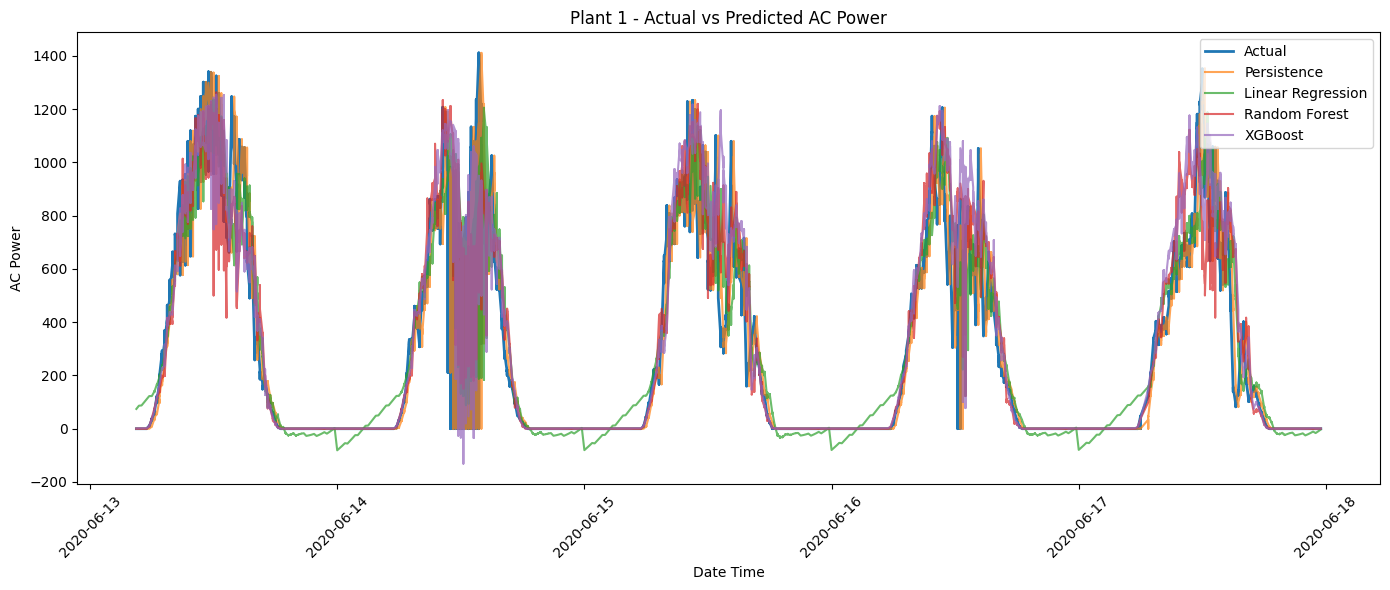

In [15]:
# What this cell does:
# Compare actual 15-minute-ahead AC power with predictions
# from Persistence, Linear Regression, Random Forest and XGBoost.

plt.figure(figsize=(14, 6))

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["TARGET_AC_POWER"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Persistence"],
    label="Persistence",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Linear_Regression"],
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Random_Forest"],
    label="Random Forest",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.title("Plant 1 - Actual vs Predicted AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

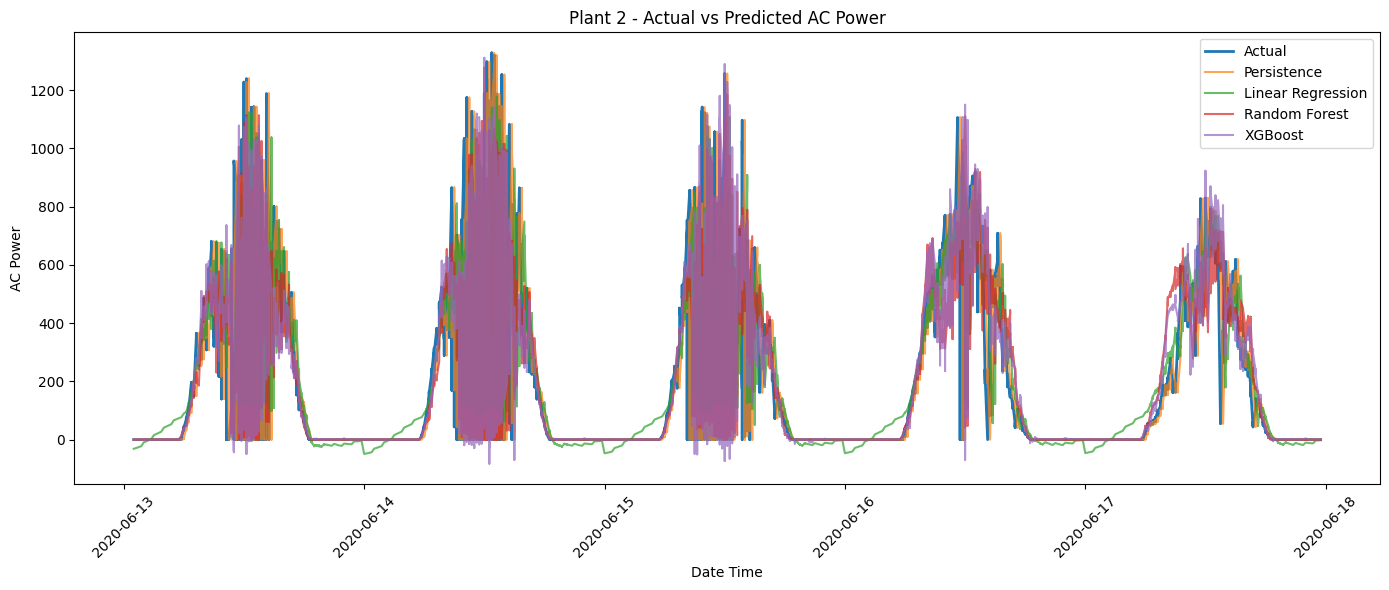

In [16]:
# What this cell does:
# Compare actual and predicted AC power for Plant 2.

plt.figure(figsize=(14, 6))

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["TARGET_AC_POWER"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Persistence"],
    label="Persistence",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Linear_Regression"],
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Random_Forest"],
    label="Random Forest",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.title("Plant 2 - Actual vs Predicted AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# What this cell does:
# Calculate prediction errors (residuals) for every model.
#
# Residual = Actual - Predicted
#
# A residual close to zero means the prediction is close
# to the actual AC power.

# Plant 1
plant1_test["Persistence_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Persistence"]
)

plant1_test["Linear_Regression_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Linear_Regression"]
)

plant1_test["Random_Forest_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Random_Forest"]
)

plant1_test["XGBoost_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["XGBoost"]
)


# Plant 2
plant2_test["Persistence_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Persistence"]
)

plant2_test["Linear_Regression_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Linear_Regression"]
)

plant2_test["Random_Forest_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Random_Forest"]
)

plant2_test["XGBoost_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["XGBoost"]
)

print("Residuals calculated successfully.")

Residuals calculated successfully.


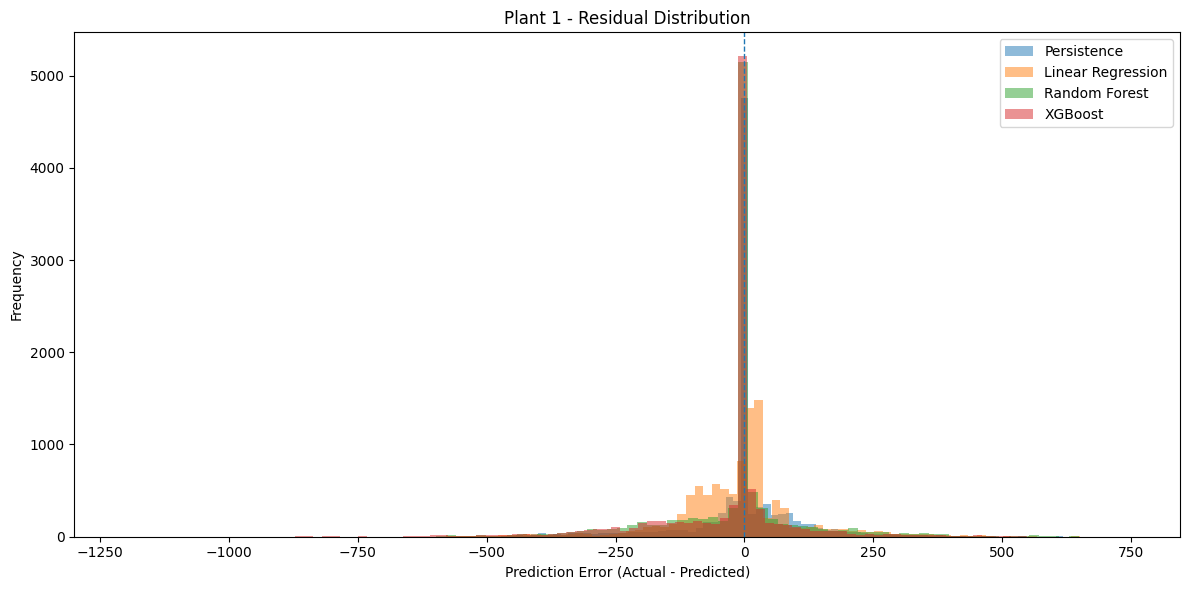

In [18]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 1.

plt.figure(figsize=(12, 6))

plt.hist(
    plant1_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant1_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant1_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant1_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 1 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

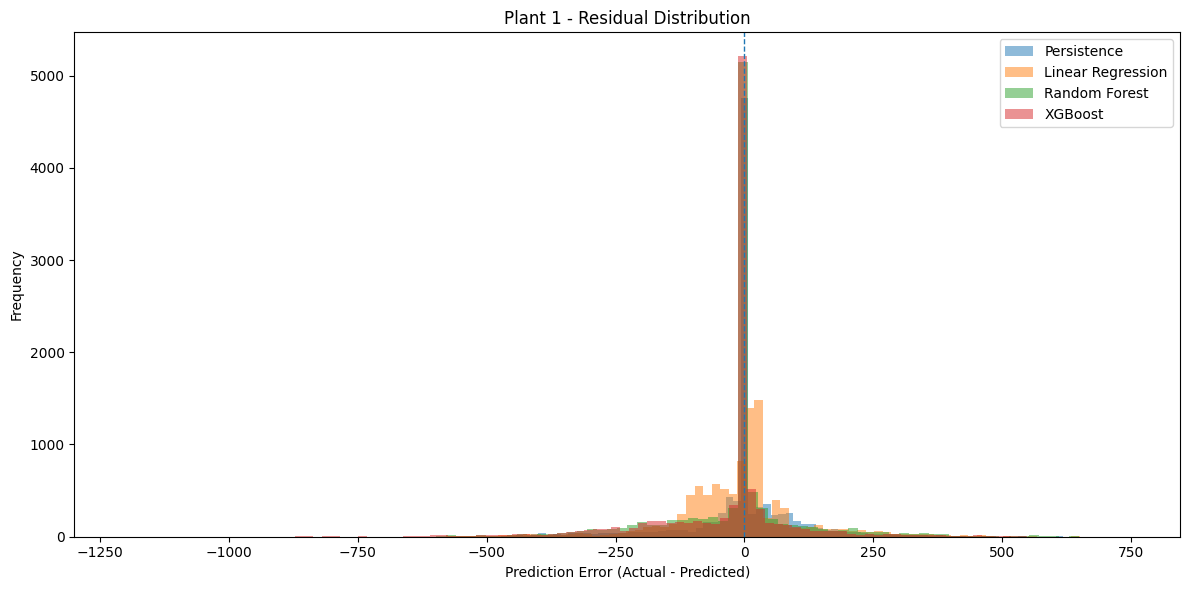

In [19]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 1.

plt.figure(figsize=(12, 6))

plt.hist(
    plant1_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant1_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant1_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant1_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 1 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

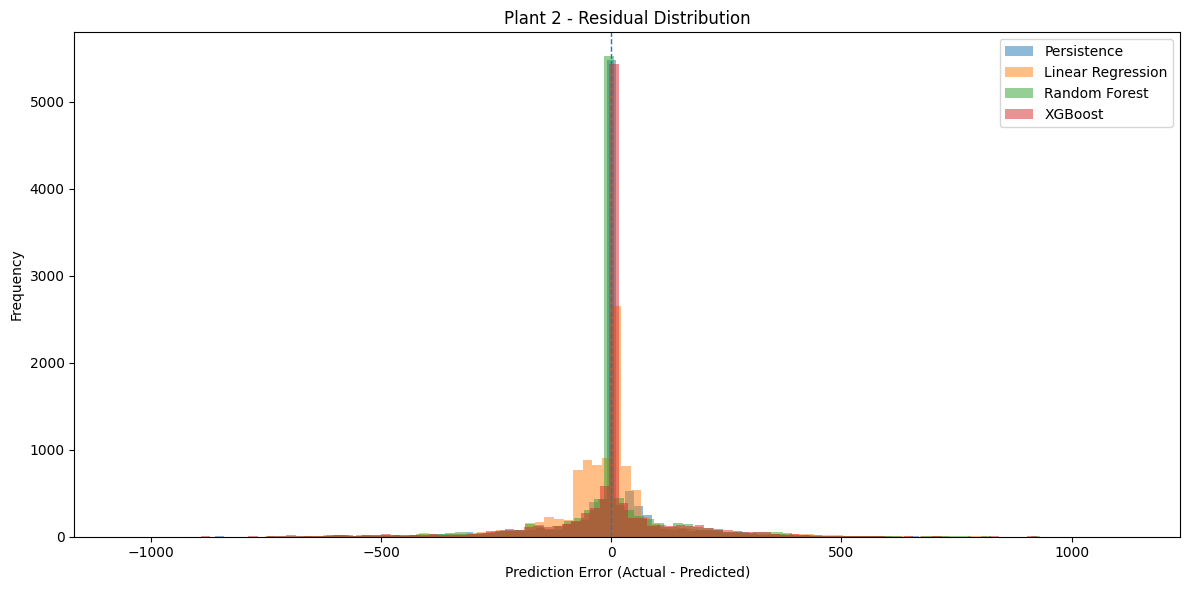

In [20]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 2.

plt.figure(figsize=(12, 6))

plt.hist(
    plant2_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant2_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant2_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant2_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 2 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

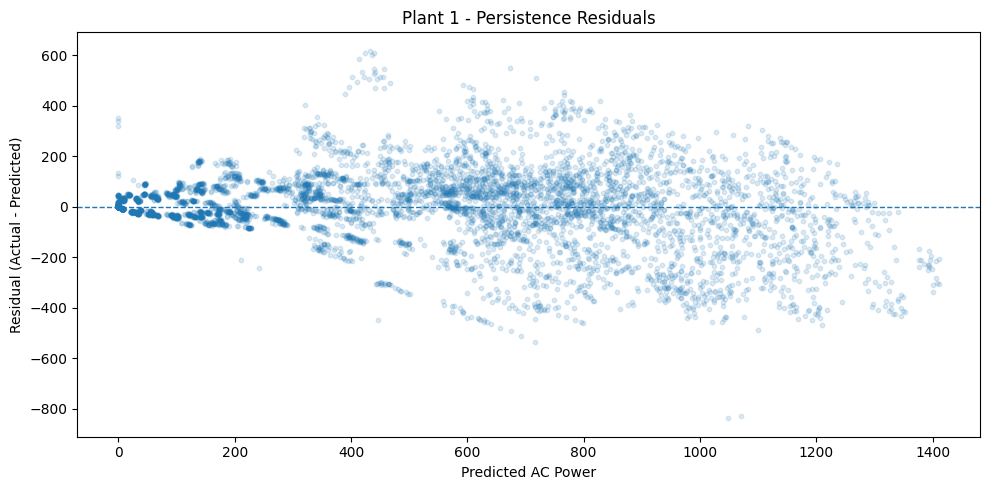

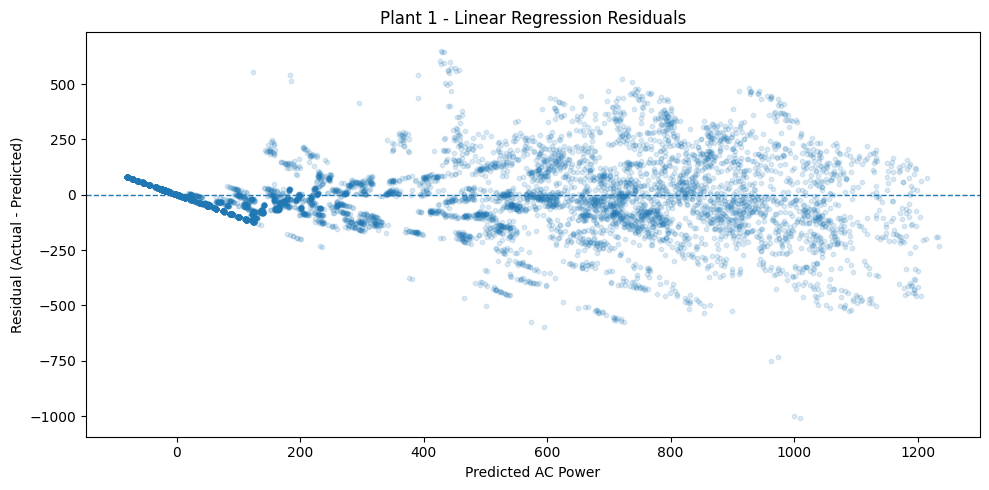

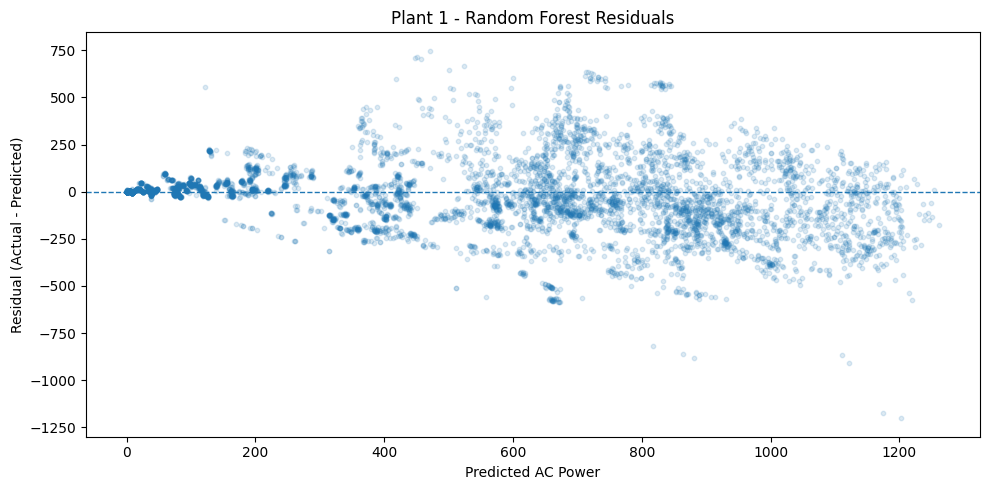

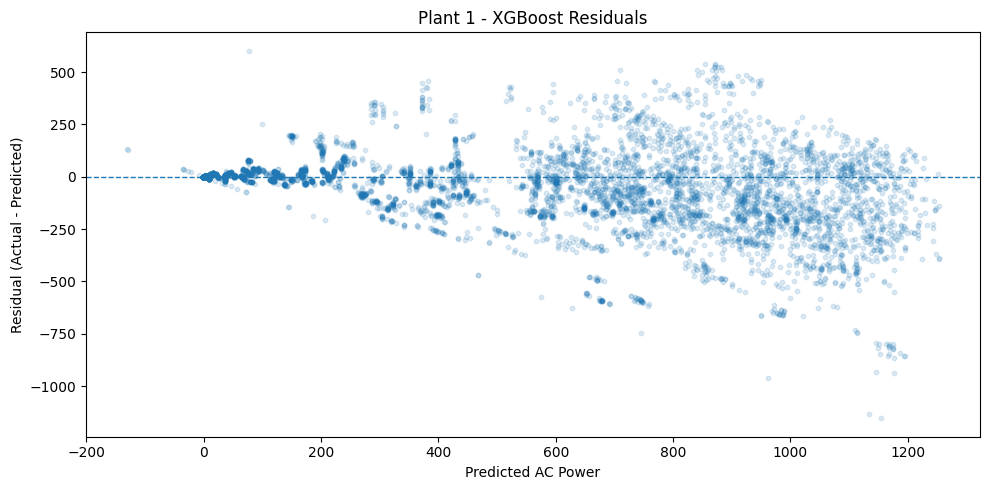

In [21]:
# What this cell does:
# Plot prediction residuals against predicted AC power.
#
# Residual = Actual - Predicted
#
# This helps us identify whether errors increase
# when the predicted solar power becomes higher.

models = [
    ("Persistence", "Persistence", "Persistence_Error"),
    ("Linear Regression", "Linear_Regression", "Linear_Regression_Error"),
    ("Random Forest", "Random_Forest", "Random_Forest_Error"),
    ("XGBoost", "XGBoost", "XGBoost_Error")
]

for model_name, prediction_column, error_column in models:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        plant1_test[prediction_column],
        plant1_test[error_column],
        alpha=0.15,
        s=10
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Predicted AC Power")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Plant 1 - {model_name} Residuals")
    plt.tight_layout()
    plt.show()

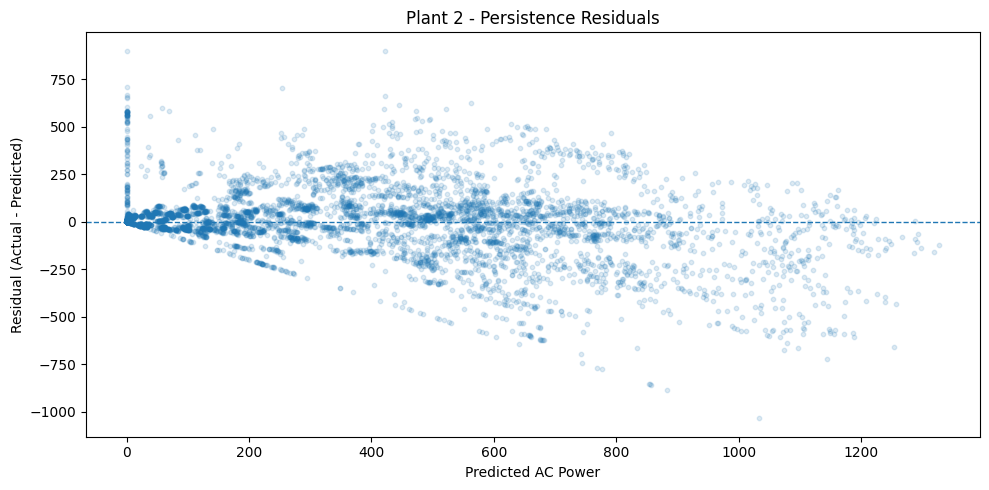

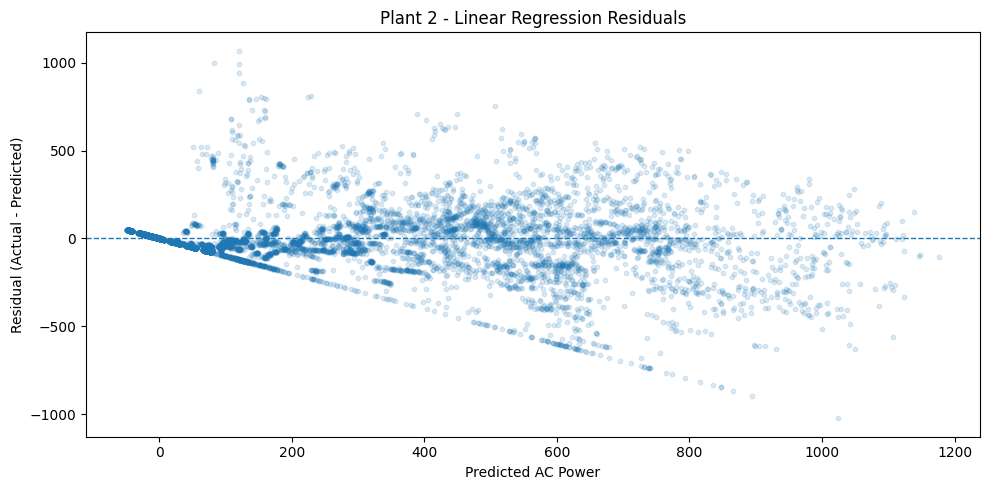

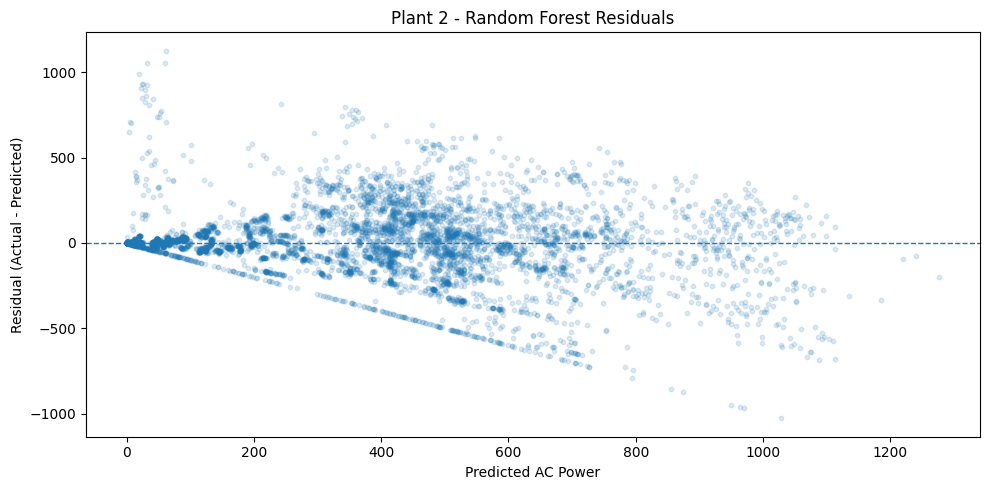

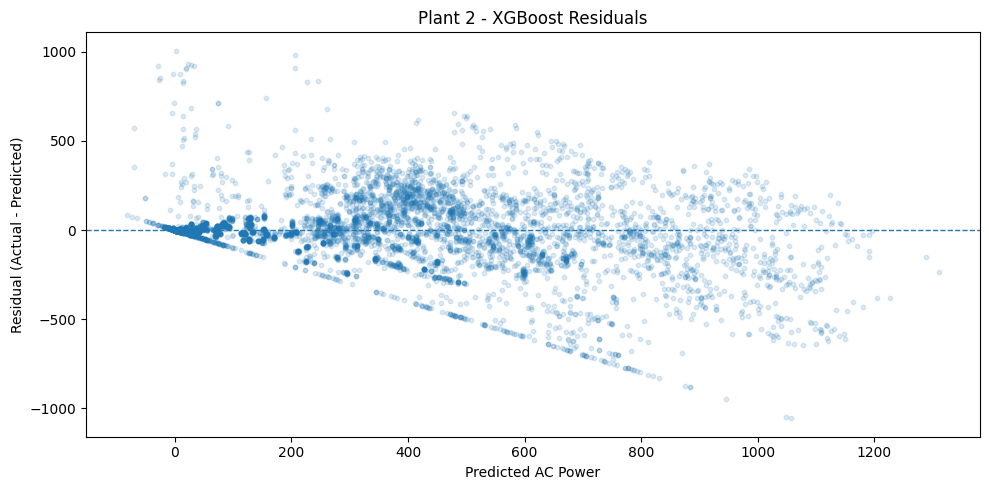

In [22]:
# What this cell does:
# Plot residuals against predicted AC power for Plant 2.
#
# We check whether prediction errors change
# with the level of predicted solar generation.

for model_name, prediction_column, error_column in models:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        plant2_test[prediction_column],
        plant2_test[error_column],
        alpha=0.15,
        s=10
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Predicted AC Power")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Plant 2 - {model_name} Residuals")
    plt.tight_layout()
    plt.show()

In [23]:
# What this cell does:
# Calculate model MAE separately for every hour of the day.
# This helps identify when the forecasting models make
# larger errors.

plant1_hourly = plant1_test.copy()

plant1_hourly["hour"] = plant1_hourly["DATE_TIME"].dt.hour

hourly_mae_p1 = plant1_hourly.groupby("hour").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"], df["XGBoost"]
        )
    })
)

hourly_mae_p1

,Persistence,Linear Regression,Random Forest,XGBoost
hour,,,,
0,0.000000,67.051496,0.000000,0.142277
1,0.000000,39.239657,0.000000,0.112176
2,0.000000,11.894635,0.000000,0.160698
3,0.000000,31.099344,0.000000,0.327955
4,0.000000,70.512518,0.000000,0.541052
5,1.178649,104.908211,0.974477,2.145450
6,45.785209,58.802220,19.736719,14.681262
7,83.045296,57.184037,72.944754,63.331339
8,63.174383,81.432644,105.406546,115.091590


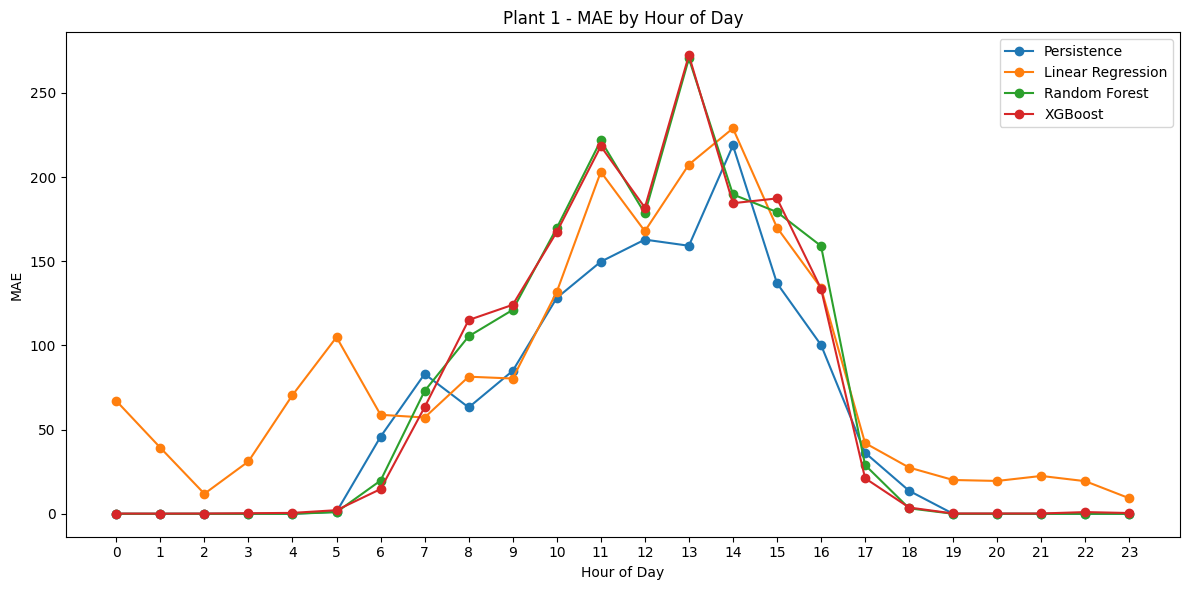

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Plant 1 - MAE by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# What this cell does:
# Calculate MAE for each hour of the day for Plant 2.

plant2_hourly = plant2_test.copy()

plant2_hourly["hour"] = plant2_hourly["DATE_TIME"].dt.hour

hourly_mae_p2 = plant2_hourly.groupby("hour").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"], df["XGBoost"]
        )
    })
)

hourly_mae_p2

,Persistence,Linear Regression,Random Forest,XGBoost
hour,,,,
0,0.000000,44.501608,0.000000,0.263907
1,0.000000,25.318030,0.000000,0.255963
2,0.000000,4.082582,0.000000,0.527568
3,0.000000,23.025267,0.000000,0.224444
4,0.000000,48.759865,0.000000,0.308091
5,1.771114,71.651508,1.517450,1.915249
6,39.849561,37.360169,29.241289,27.188777
7,59.631212,51.527830,62.395908,48.099728
8,100.218523,105.162669,162.335636,155.565342


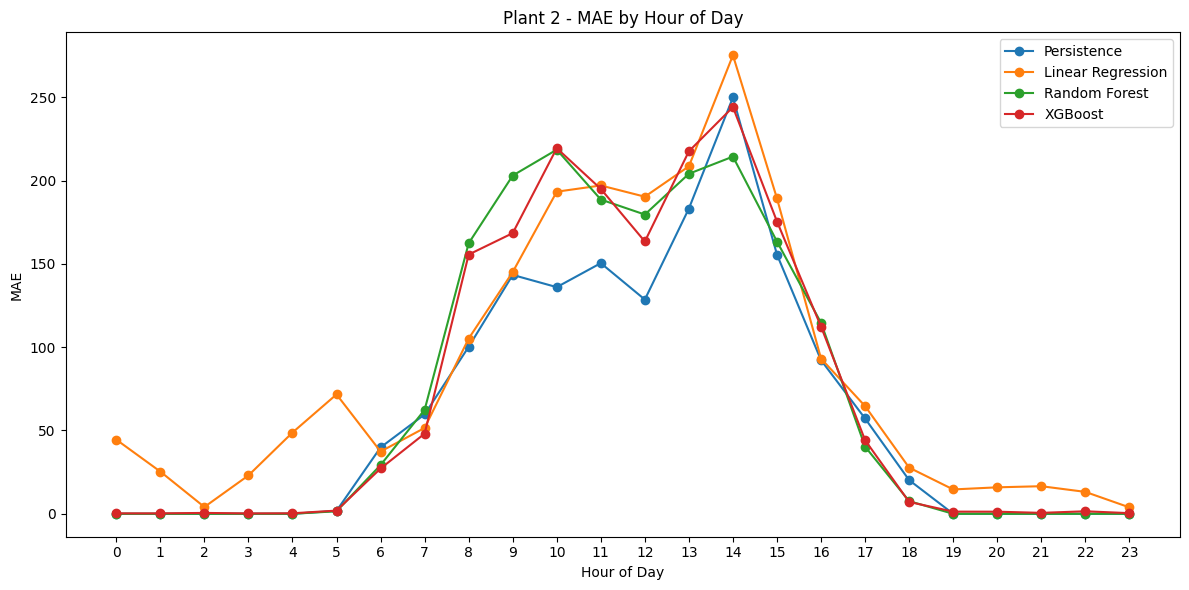

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Plant 2 - MAE by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# What this cell does:
# Divide Plant 1 test observations into irradiation ranges
# and calculate model MAE for each range.

plant1_irr = plant1_test.copy()

plant1_irr["irradiation_level"] = pd.cut(
    plant1_irr["IRRADIATION"],
    bins=[-0.001, 0.05, 0.2, 0.5, 1.0, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

irradiation_mae_p1 = plant1_irr.groupby(
    "irradiation_level",
    observed=True
).apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

irradiation_mae_p1

,Persistence,Linear Regression,Random Forest,XGBoost
irradiation_level,,,,
Very Low,3.517920,38.600622,1.100566,1.371166
Low,55.823022,74.408423,84.666859,72.827422
Medium,116.597218,127.164647,149.417963,161.025136
High,150.551077,173.022975,184.458811,175.698786
Very High,233.047673,110.459169,294.889509,212.514455


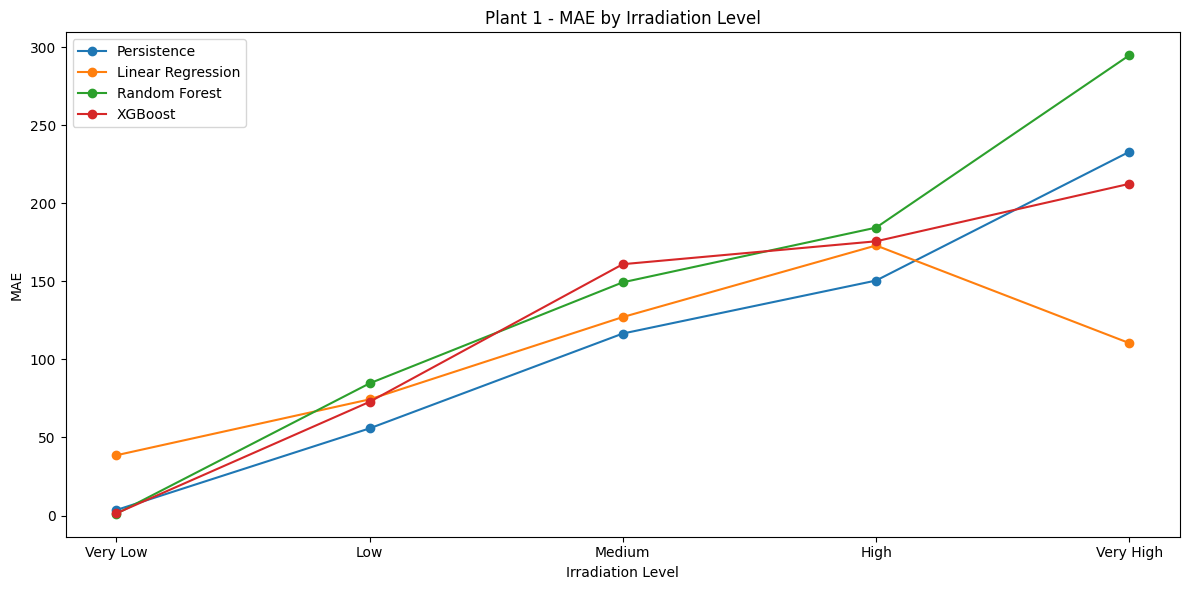

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Irradiation Level")
plt.ylabel("MAE")
plt.title("Plant 1 - MAE by Irradiation Level")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# What this cell does:
# Calculate model MAE for different irradiation levels
# for Plant 2.

plant2_irr = plant2_test.copy()

plant2_irr["irradiation_level"] = pd.cut(
    plant2_irr["IRRADIATION"],
    bins=[-0.001, 0.05, 0.2, 0.5, 1.0, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

irradiation_mae_p2 = plant2_irr.groupby(
    "irradiation_level",
    observed=True
).apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

irradiation_mae_p2

,Persistence,Linear Regression,Random Forest,XGBoost
irradiation_level,,,,
Very Low,3.310330,26.776886,1.969541,2.616488
Low,63.776236,67.664458,92.106459,80.497632
Medium,148.684414,162.491633,159.343860,166.721568
High,159.833325,209.108510,206.676900,201.565227


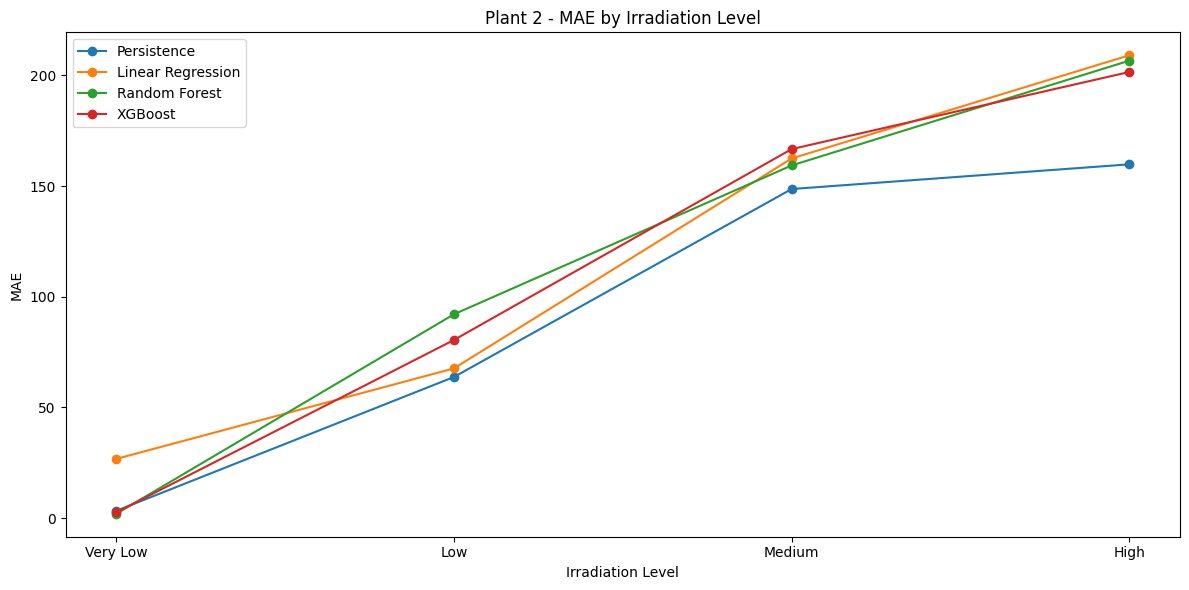

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Irradiation Level")
plt.ylabel("MAE")
plt.title("Plant 2 - MAE by Irradiation Level")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# What this cell does:
# Calculate MAE for each inverter (SOURCE_KEY)
# for all forecasting models on Plant 1 test data.

plant1_inverter_mae = plant1_test.groupby("SOURCE_KEY").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

plant1_inverter_mae

,Persistence,Linear Regression,Random Forest,XGBoost
SOURCE_KEY,,,,
1BY6WEcLGh8j5v7,57.872922,86.018015,81.174659,79.183898
1IF53ai7Xc0U56Y,59.899471,86.934835,73.584762,70.872394
3PZuoBAID5Wc2HD,64.996250,87.026492,75.237585,72.534965
7JYdWkrLSPkdwr4,60.250202,85.174825,74.927962,73.847206
McdE0feGgRqW7Ca,59.616402,84.548050,73.199019,73.623431
VHMLBKoKgIrUVDU,63.049611,87.607981,74.613968,71.249874
WRmjgnKYAwPKWDb,64.633606,87.316614,77.782615,74.448418
YxYtjZvoooNbGkE,61.749619,85.442807,75.807099,76.202021
ZnxXDlPa8U1GXgE,60.810815,85.105230,73.031383,72.562658


In [32]:
# What this cell does:
# Calculate MAE for each inverter (SOURCE_KEY)
# for all forecasting models on Plant 2 test data.

plant2_inverter_mae = plant2_test.groupby("SOURCE_KEY").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

plant2_inverter_mae

,Persistence,Linear Regression,Random Forest,XGBoost
SOURCE_KEY,,,,
4UPUqMRk7TRMgml,58.260898,91.415926,76.021540,74.242442
81aHJ1q11NBPMrL,71.867192,86.582764,77.599274,79.106732
9kRcWv60rDACzjR,61.418703,84.305264,71.040575,71.963011
Et9kgGMDl729KT4,54.703252,85.587940,74.309426,72.793077
IQ2d7wF4YD8zU1Q,68.108158,88.824984,77.370742,75.332539
LYwnQax7tkwH5Cb,67.410498,82.270260,72.604377,71.852561
LlT2YUhhzqhg5Sw,62.196694,85.301016,71.048199,71.178952
Mx2yZCDsyf6DPfv,57.221548,84.449289,70.157748,71.475787
NgDl19wMapZy17u,69.345572,90.629907,80.897402,82.014284


In [33]:
# What this cell does:
# Save inverter-level model performance
# for later analysis and the final report.

TABLES_PATH = "../outputs/tables/"
os.makedirs(TABLES_PATH, exist_ok=True)

plant1_inverter_mae.to_csv(
    TABLES_PATH + "plant1_inverter_mae.csv"
)

plant2_inverter_mae.to_csv(
    TABLES_PATH + "plant2_inverter_mae.csv"
)

print("Inverter-level MAE results saved successfully.")

Inverter-level MAE results saved successfully.


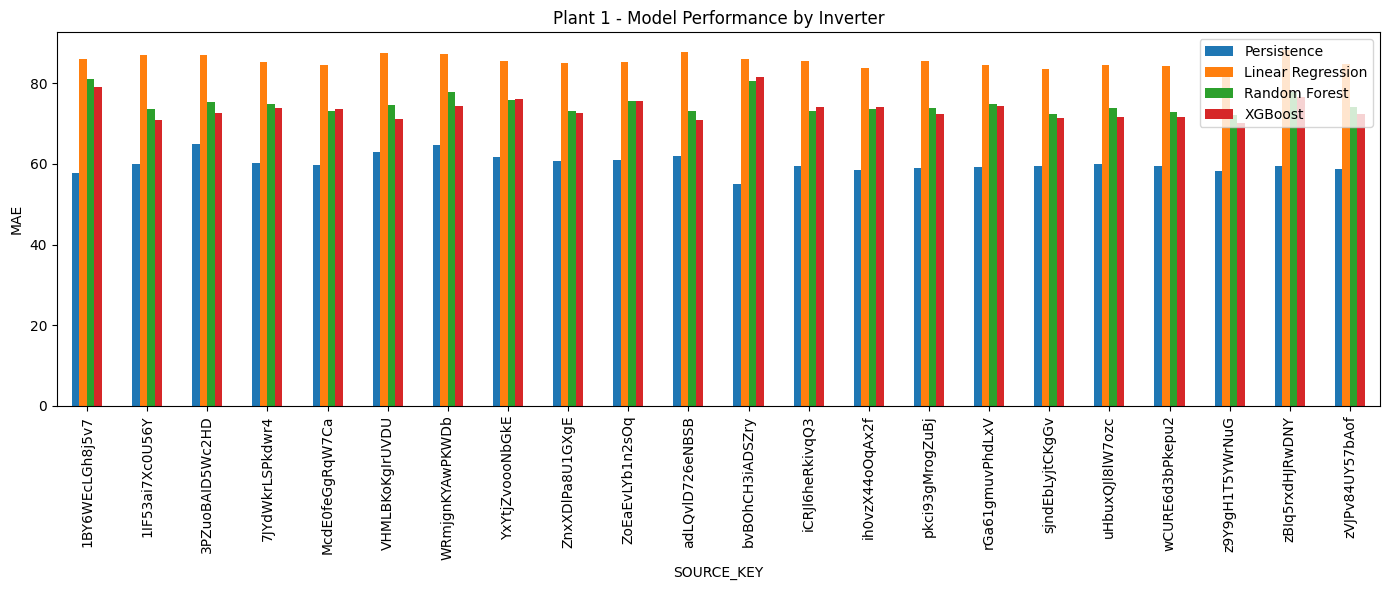

In [34]:
# What this cell does:
# Compare model MAE across individual inverters for Plant 1.

plant1_inverter_mae.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("SOURCE_KEY")
plt.ylabel("MAE")
plt.title("Plant 1 - Model Performance by Inverter")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

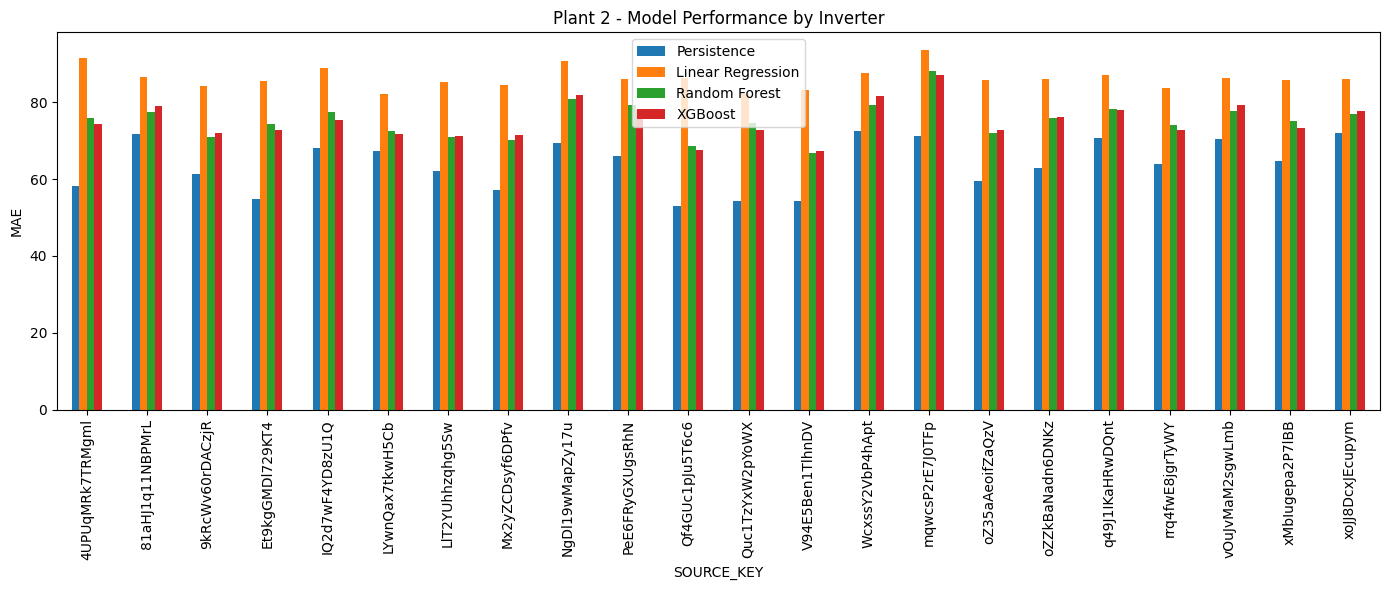

In [35]:
# What this cell does:
# Compare model MAE across individual inverters for Plant 2.

plant2_inverter_mae.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("SOURCE_KEY")
plt.ylabel("MAE")
plt.title("Plant 2 - Model Performance by Inverter")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# What this cell does:
# Calculate and summarize final TEST performance
# for all models on Plant 1 and Plant 2.

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# -----------------------------
# Plant 1
# -----------------------------

p1_persistence = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Persistence"]
)

p1_linear = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Linear_Regression"]
)

p1_rf = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Random_Forest"]
)

p1_xgb = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["XGBoost"]
)


# -----------------------------
# Plant 2
# -----------------------------

p2_persistence = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Persistence"]
)

p2_linear = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Linear_Regression"]
)

p2_rf = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Random_Forest"]
)

p2_xgb = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["XGBoost"]
)


# -----------------------------
# Create final comparison table
# -----------------------------

final_model_results = pd.DataFrame({

    "Plant": [
        "Plant 1",
        "Plant 1",
        "Plant 1",
        "Plant 1",
        "Plant 2",
        "Plant 2",
        "Plant 2",
        "Plant 2"
    ],

    "Model": [
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        p1_persistence[0],
        p1_linear[0],
        p1_rf[0],
        p1_xgb[0],
        p2_persistence[0],
        p2_linear[0],
        p2_rf[0],
        p2_xgb[0]
    ],

    "RMSE": [
        p1_persistence[1],
        p1_linear[1],
        p1_rf[1],
        p1_xgb[1],
        p2_persistence[1],
        p2_linear[1],
        p2_rf[1],
        p2_xgb[1]
    ],

    "R2": [
        p1_persistence[2],
        p1_linear[2],
        p1_rf[2],
        p1_xgb[2],
        p2_persistence[2],
        p2_linear[2],
        p2_rf[2],
        p2_xgb[2]
    ]
})

final_model_results

,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.104635,113.125207,0.911338
1,Plant 1,Linear Regression,85.516846,131.385266,0.880405
2,Plant 1,Random Forest,74.890714,141.625563,0.861036
3,Plant 1,XGBoost,73.691786,144.877442,0.854581
4,Plant 2,Persistence,63.918273,132.196674,0.803117
5,Plant 2,Linear Regression,86.336363,149.477321,0.748280
6,Plant 2,Random Forest,75.345363,152.383437,0.738397
7,Plant 2,XGBoost,75.207770,152.409932,0.738306


In [38]:
# What this cell does:
# Save the final test-set model comparison.

METRICS_PATH = "../outputs/metrics/"
os.makedirs(METRICS_PATH, exist_ok=True)

final_model_results.to_csv(
    METRICS_PATH + "final_model_results.csv",
    index=False
)

print("Final model results saved successfully.")

Final model results saved successfully.


In [39]:
# What this cell does:
# Find the model with the lowest MAE separately
# for Plant 1 and Plant 2.

best_models = (
    final_model_results
    .loc[final_model_results.groupby("Plant")["MAE"].idxmin()]
    .reset_index(drop=True)
)

print("Best model based on MAE:")
display(best_models)

Best model based on MAE:


,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.104635,113.125207,0.911338
1,Plant 2,Persistence,63.918273,132.196674,0.803117


In [ ]:
One important correction before we start
For the Digital Twin, we should not simply use the persistence model and stop there. We need to preserve the forecasting-model comparison and then construct the expected-power engine in a way that supports the later inverter anomaly detection and scenario simulation stages.
So don't create any new model yet.